In [1]:
from datafusion import SessionContext
import polars as pl
import matplotlib.pyplot as plt

In [2]:
ctx = SessionContext()

# DataFusion's CSV parser can struggle with complex quoted fields;
# use Polars to read the CSV and register via Arrow for robustness
df_raw = pl.read_csv('data/MrBeast_youtube_stats.csv', try_parse_dates=False, infer_schema_length=1000)
ctx.register_record_batches('youtube_stats', [df_raw.to_arrow().to_batches()])

ctx.sql('SELECT * FROM youtube_stats LIMIT 3').show()

DataFrame()
+-------------+-------------------------------------------------+-------------------------------------------------------------------------------------------------------------------------------+---------------------------+---------------+------------------+-------------+-----------+--------------+------------------------------------------------+--------------------------+---------------------------+--------------------------------------------------+-------------------------+--------------------------+--------------------------------------------------+-----------------------+------------------------+-------------------------+--------------------------+-----------------------------------------------------------------------------------------------------------------------------------------+-------------------------+-------------------------------------------------+--------------------------------------------------------------------------------------------------------------------

In [3]:
ctx.sql('''
    SELECT id, COUNT(DISTINCT title) AS title_count
    FROM youtube_stats
    GROUP BY id
    ORDER BY title_count DESC
''').show()

DataFrame()
+-------------+-------------+
| id          | title_count |
+-------------+-------------+
|             | 12          |
| 0CTp1a-aCUM | 5           |
| 65fN_OUawjk | 4           |
| vBpQ1SlfVtU | 4           |
| 2isYuQZMbdU | 4           |
| KkCXLABwHP0 | 3           |
| QbJJwaVdgIs | 3           |
| 48h57PspBec | 3           |
| lOKASgtr6kU | 3           |
| zajUgQLviwk | 3           |
| hTSaweR8qMI | 3           |
| tVWWp1PqDus | 3           |
| vaIgyRoUkQI | 3           |
| jdMNoQE3mIQ | 3           |
| iogcY_4xGjo | 3           |
| jObOjhUkf50 | 3           |
| 1WEAJ-DFkHE | 3           |
| 7ESeQBeikKs | 3           |
| 9RhWXPcKBI8 | 3           |
| mKdjycj-7eE | 3           |
+-------------+-------------+


In [4]:
# Parse dates, cast numerics to correct types, drop nulls,
# and rename camelCase columns -> snake_case for cleaner downstream SQL
ctx.sql('''
    CREATE OR REPLACE VIEW youtube_clean AS
    SELECT
        id,
        title,
        CAST(pull_date AS TIMESTAMP) AS pull_date,
        CAST("viewCount"    AS BIGINT) AS view_count,
        CAST("likeCount"    AS BIGINT) AS like_count,
        CAST("commentCount" AS BIGINT) AS comment_count,
        CAST(duration_seconds AS DOUBLE) AS duration_seconds
    FROM youtube_stats
    WHERE "viewCount"    IS NOT NULL
      AND "likeCount"    IS NOT NULL
      AND "commentCount" IS NOT NULL
''')
ctx.sql('SELECT * FROM youtube_clean LIMIT 3').show()

DataFrame()
+-------------+-------------------------------------------------+----------------------------+------------+------------+---------------+------------------+
| id          | title                                           | pull_date                  | view_count | like_count | comment_count | duration_seconds |
+-------------+-------------------------------------------------+----------------------------+------------+------------+---------------+------------------+
| gsWPpE4Rid0 | Videos I Could Not Upload...                    | 2024-11-02T00:04:48.764904 | 165484611  | 4072057    | 66063         | 812.0            |
| DuQbOQwVaNE | Offering People $100,000 To Quit Their Job      | 2024-11-02T00:04:48.764904 | 150540760  | 3483344    | 112924        | 627.0            |
| U_LlX4t0A9I | $10,000 Every Day You Survive In The Wilderness | 2024-11-02T00:04:48.764904 | 210214774  | 7595531    | 333491        | 1570.0           |
+-------------+-------------------------------------

<Axes: title={'center': 'Number of Videos pulled per day'}, xlabel='pull_date'>

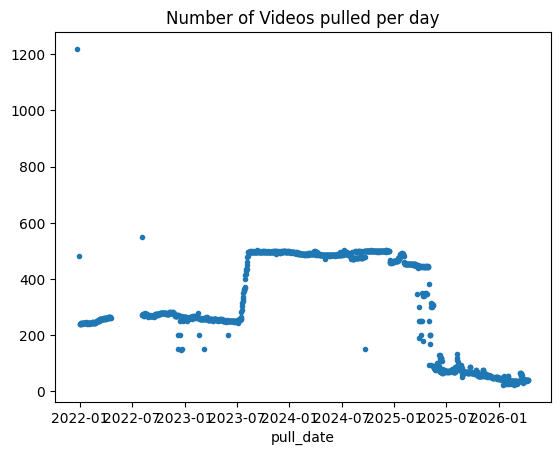

In [5]:
(ctx.sql('''
    SELECT CAST(pull_date AS DATE) AS pull_date, COUNT(*) AS cnt
    FROM youtube_clean
    GROUP BY CAST(pull_date AS DATE)
    ORDER BY pull_date
''')
.to_pandas()
.set_index('pull_date')['cnt']
.plot(style='.', title='Number of Videos pulled per day'))

In [6]:
ctx.sql('''
    SELECT id, title, MAX(view_count) AS view_count, MAX(pull_date) AS pull_date
    FROM youtube_clean
    GROUP BY id, title
    ORDER BY view_count ASC
''').show()

DataFrame()
+-------------+----------------------------------------------------------+------------+----------------------------+
| id          | title                                                    | view_count | pull_date                  |
+-------------+----------------------------------------------------------+------------+----------------------------+
| F3fmzCmIJ14 | This Stream Ends When Someone Wins $1,000,000            | 0          | 2026-04-05T00:06:18.400542 |
| TGKkMl17Htg | Battle Pirates, Unstoppable Ship!                        | 35956      | 2023-08-07T00:09:55.117235 |
| ywZy_Fo2ydo | Modern Art Is A Joke                                     | 36613      | 2023-08-27T00:12:06.324381 |
| u6t4jrhs56Q | Top Youtube &quot;ShoutOuts&quot;                        | 36633      | 2023-08-27T00:12:06.324381 |
| 6T17licWsQ4 | Leaving For 7 Days                                       | 39197      | 2023-07-24T00:13:41.788641 |
| GfgcVOuHLAo | Every FaZe Video Ever #karnageRC    

<Axes: xlabel='pull_date'>

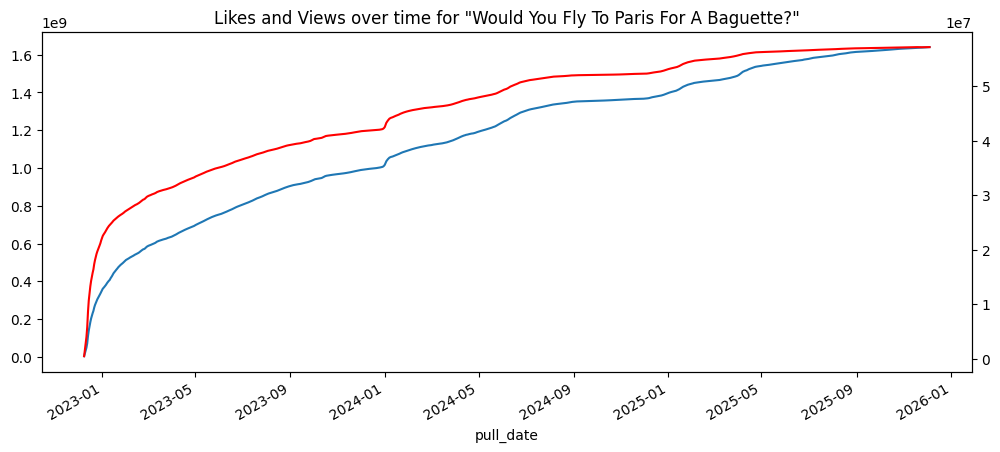

In [7]:
video_name = ctx.sql('''
    SELECT title FROM youtube_clean WHERE id = 'se50viFJ0AQ' LIMIT 1
''').to_pandas()['title'][0]

video_df = ctx.sql('''
    SELECT pull_date, view_count, like_count
    FROM youtube_clean
    WHERE id = 'se50viFJ0AQ'
    ORDER BY pull_date
''').to_pandas().set_index('pull_date')

fig, ax = plt.subplots(figsize=(12, 5))
ax2 = ax.twinx()
video_df['view_count'].plot(ax=ax, title=f'Likes and Views over time for "{video_name}"')
video_df['like_count'].plot(ax=ax2, color='red')

In [8]:
ctx.register_parquet('youtube_processed', 'data/MrBeast_youtube_stats_processed.parquet')

# Rename camelCase -> snake_case and select only the columns needed downstream
ctx.sql('''
    CREATE OR REPLACE VIEW youtube_base AS
    SELECT
        id, title, pull_date,
        "viewCount"    AS view_count,
        "likeCount"    AS like_count,
        "commentCount" AS comment_count,
        duration_seconds,
        time_since_last_pull,
        view_diff,
        like_diff,
        comment_diff
    FROM youtube_processed
''')
ctx.sql('SELECT * FROM youtube_base LIMIT 3').show()

DataFrame()
+-------------+-------------------------------------------------+-----------------------------+------------+------------+---------------+------------------+----------------------+-----------+-----------+--------------+
| id          | title                                           | pull_date                   | view_count | like_count | comment_count | duration_seconds | time_since_last_pull | view_diff | like_diff | comment_diff |
+-------------+-------------------------------------------------+-----------------------------+------------+------------+---------------+------------------+----------------------+-----------+-----------+--------------+
| -0zoWMSEOGg | I Gave My 6,000,000th Subscriber 6,000,000 ____ | 2021-12-24T01:41:03.667334Z | 15052568   | 353973     | 33234         | 1113             |                      |           |           |              |
| -0zoWMSEOGg | I Gave My 6,000,000th Subscriber 6,000,000 ____ | 2021-12-24T01:53:57.197204Z | 15052587   | 353

In [9]:
ctx.sql('''
    CREATE OR REPLACE VIEW youtube_ratios AS
    SELECT *,
        like_diff / NULLIF(view_diff, 0) AS like_to_view_ratio
    FROM youtube_base
''')

No data to display

In [10]:
ctx.sql('''
    SELECT id, title, pull_date, view_diff, like_diff, like_to_view_ratio
    FROM youtube_ratios
    WHERE view_diff != 0
    ORDER BY like_to_view_ratio DESC
''').show()

DataFrame()
+-------------+--------------------------------------------------+-----------------------------+-----------+-----------+--------------------+
| id          | title                                            | pull_date                   | view_diff | like_diff | like_to_view_ratio |
+-------------+--------------------------------------------------+-----------------------------+-----------+-----------+--------------------+
| uotb9ZHnI2g | Tipping Pizza Delivery Guys $10,000              | 2024-05-08T00:10:49.880176Z | 309.0     | 695773.0  | 2251.6925566343043 |
| 93s1JECSy60 | Giving My Mom $100,000 (Proudest Day Of My Life) | 2024-05-08T00:10:49.880176Z | 1021.0    | 1529468.0 | 1498.0097943192948 |
| _uwNDiU04zE | I Donated $300,000 To People In Need             | 2024-09-21T00:07:46.820812Z | -1.0      | -167.0    | 167.0              |
| _uwNDiU04zE | I Donated $300,000 To People In Need             | 2024-08-05T00:06:32.183949Z | -1.0      | -164.0    | 164.0          

<Axes: xlabel='pull_date'>

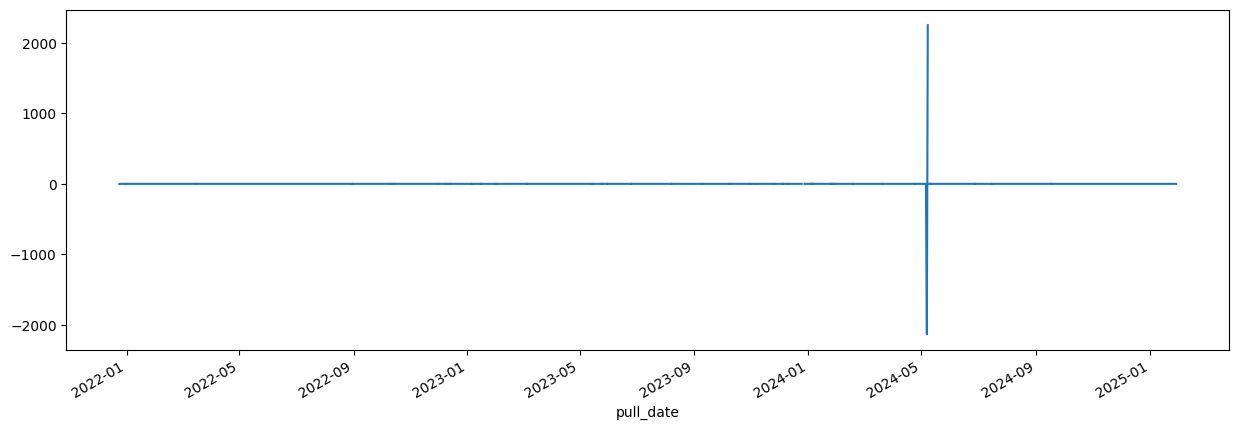

In [11]:
ctx.sql('''
    SELECT pull_date, like_to_view_ratio
    FROM youtube_ratios
    WHERE id = 'uotb9ZHnI2g'
    ORDER BY pull_date
''').to_pandas().set_index('pull_date')['like_to_view_ratio'].plot(figsize=(15, 5))

In [12]:
# time_since_last_pull is stored as Arrow Duration[us].
# CAST to BIGINT yields microseconds; divide by 1e6 -> seconds, then by 43200 -> 12-hour periods
ctx.sql('''
    CREATE OR REPLACE VIEW youtube_normalized AS
    SELECT *,
        view_diff / (CAST(time_since_last_pull AS BIGINT) / 1e6 / (60.0 * 60.0 * 12.0)) AS view_diff_norm,
        like_diff / (CAST(time_since_last_pull AS BIGINT) / 1e6 / (60.0 * 60.0 * 12.0)) AS like_diff_norm
    FROM youtube_ratios
''')

No data to display

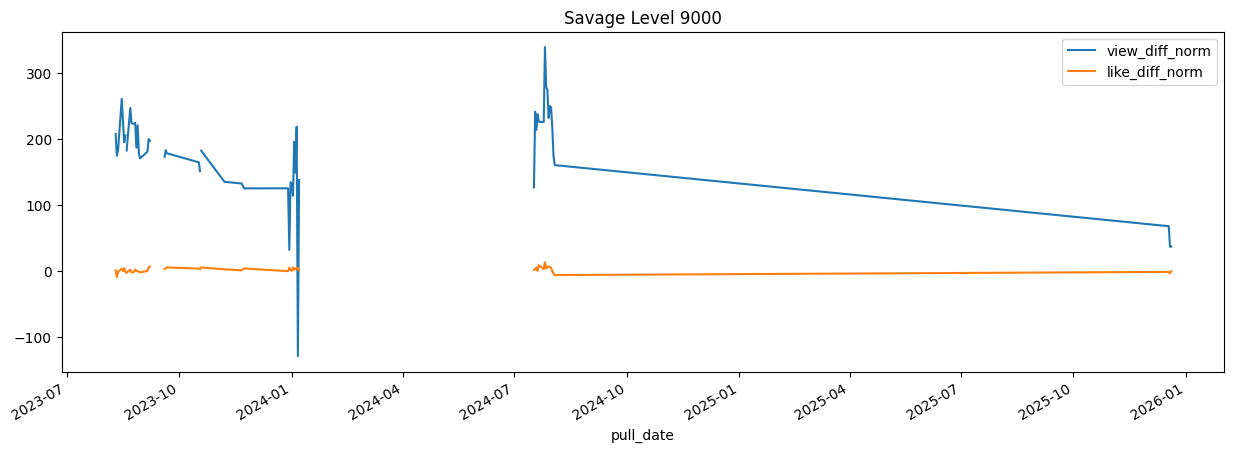

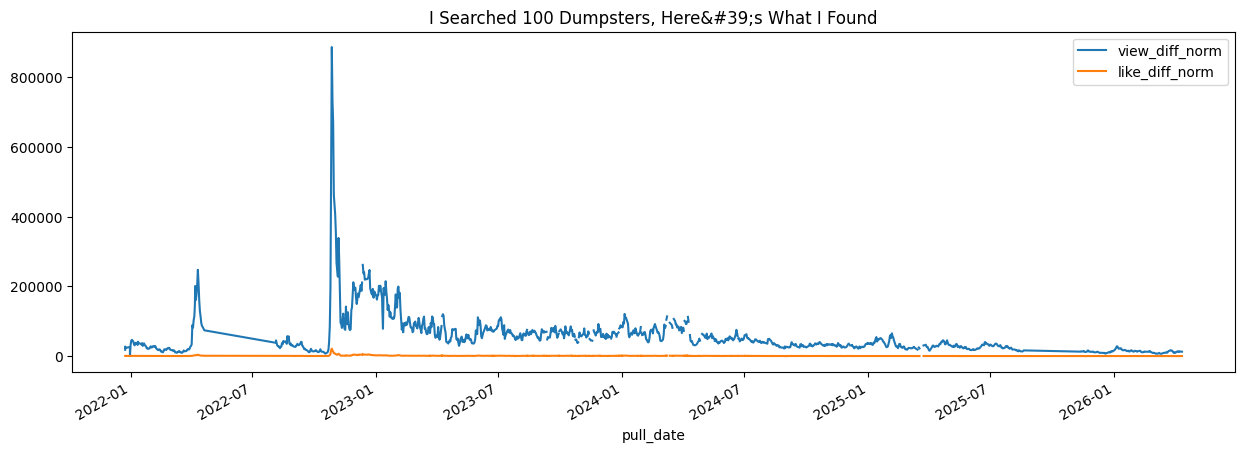

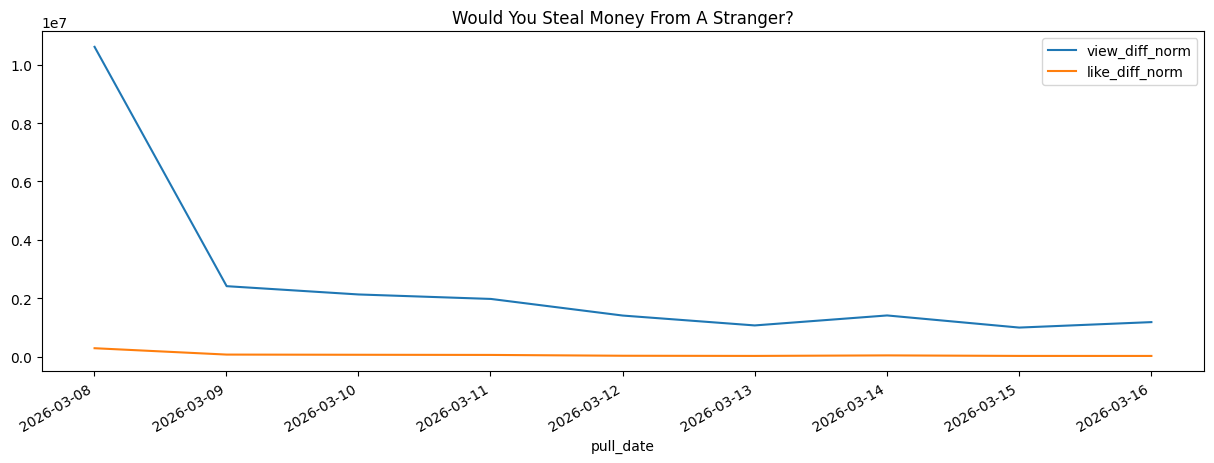

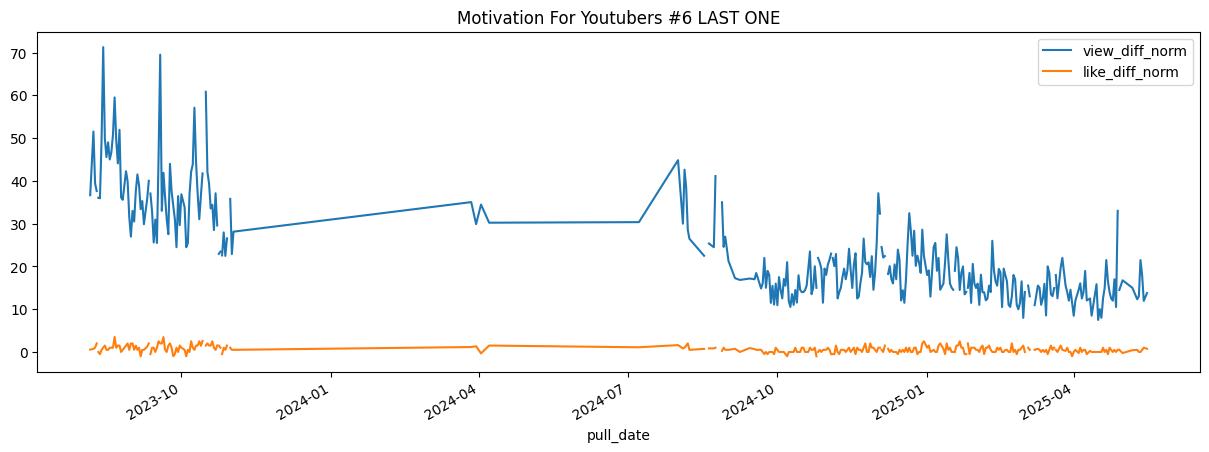

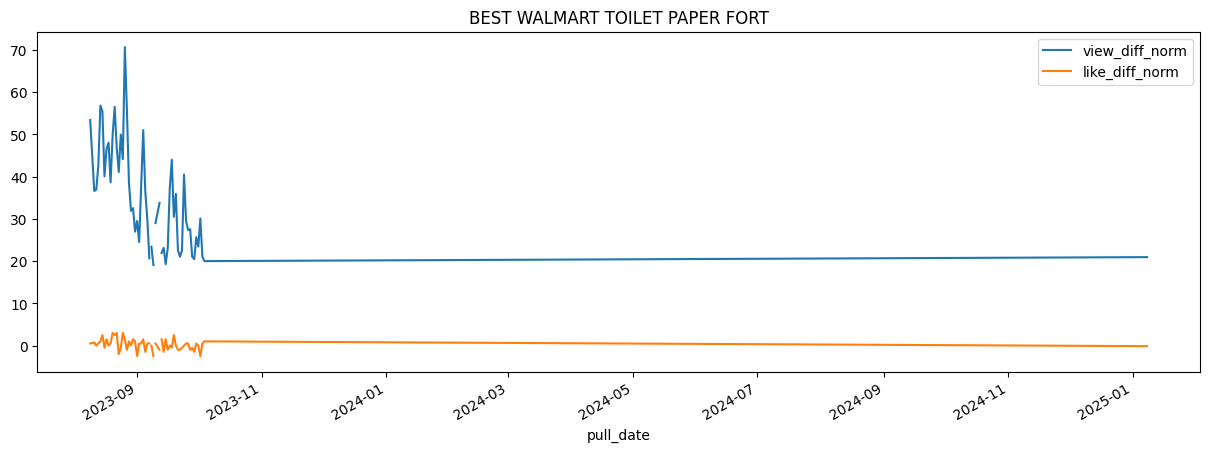

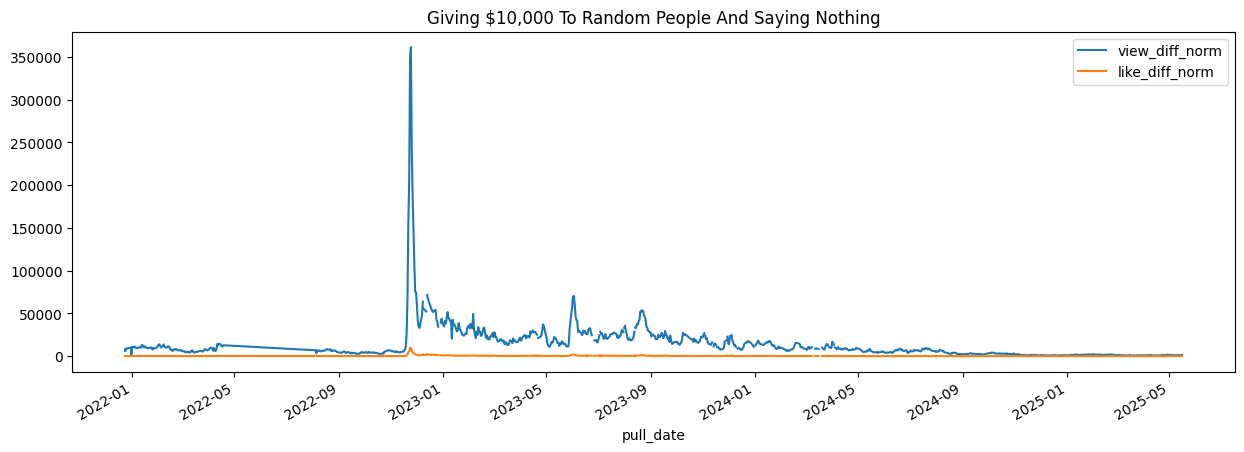

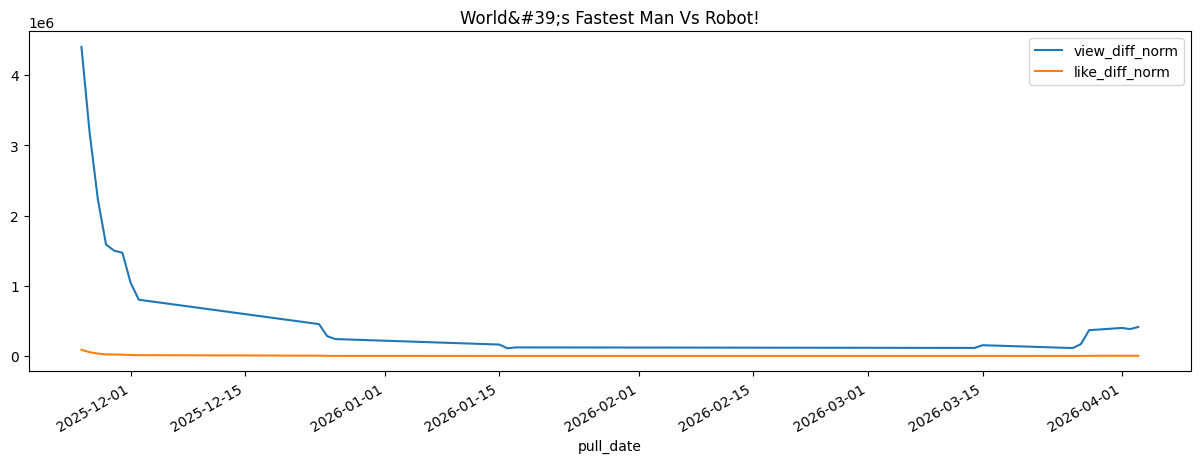

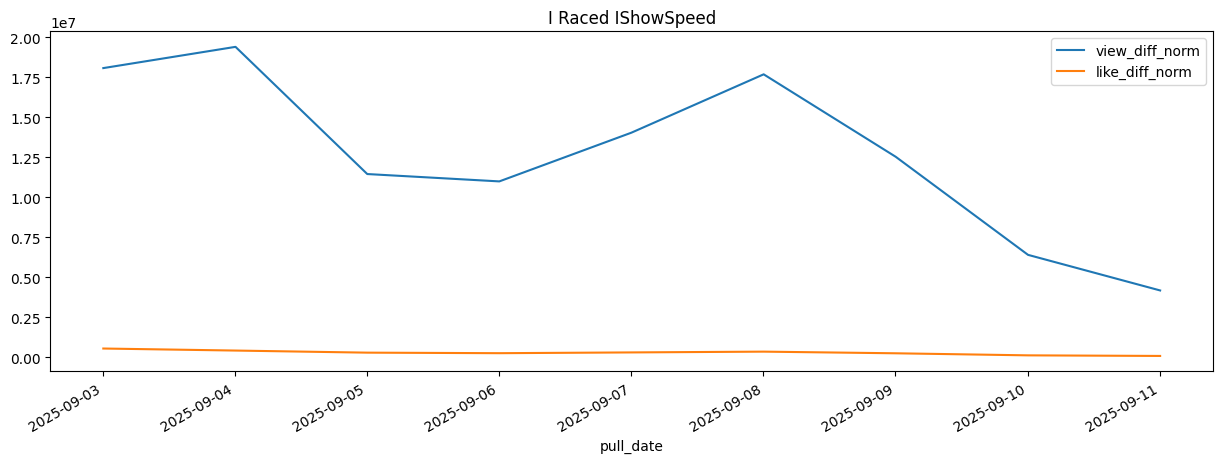

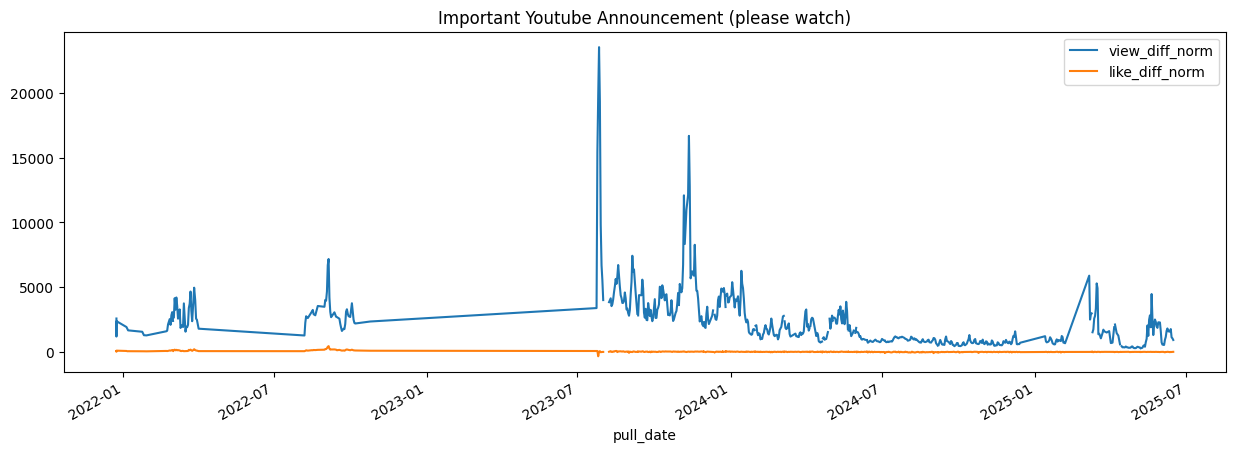

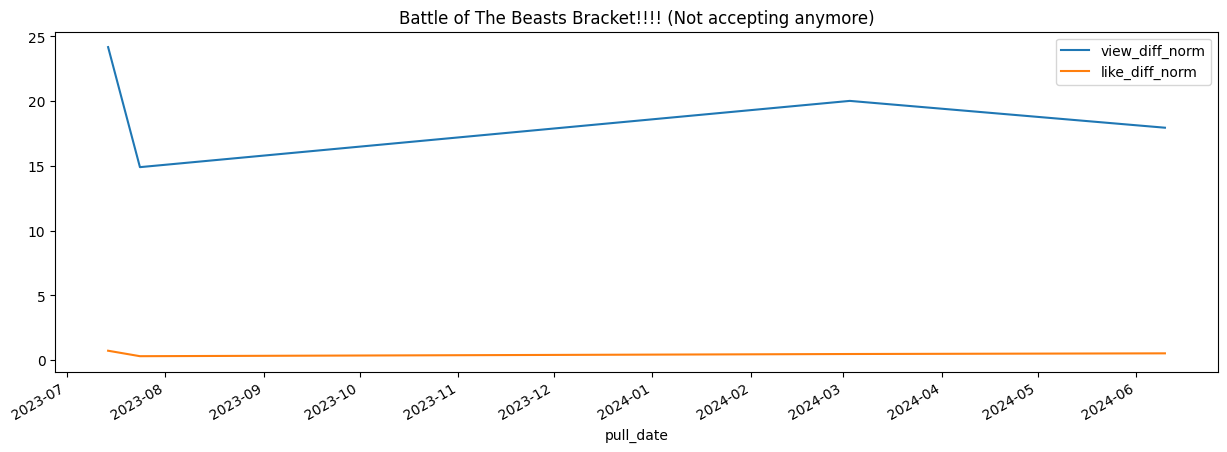

In [13]:
import random

all_ids = ctx.sql('SELECT DISTINCT id FROM youtube_normalized').to_pandas()['id'].tolist()
random.seed(529)
random_vids = random.sample(all_ids, 10)

for v in random_vids:
    vid_title = ctx.sql(
        f"SELECT title FROM youtube_normalized WHERE id = '{v}' LIMIT 1"
    ).to_pandas()['title'][0]
    query = f"SELECT pull_date, view_diff_norm, like_diff_norm FROM youtube_normalized WHERE id = '{v}' ORDER BY pull_date"
    (ctx.sql(query)
     .to_pandas()
     .set_index('pull_date')[['view_diff_norm', 'like_diff_norm']]
     .plot(figsize=(15, 5), title=vid_title))

## Look at videos with crazy ratios

In [14]:
ctx.sql('''
    CREATE OR REPLACE VIEW youtube_final AS
    SELECT *,
        like_diff_norm / NULLIF(view_diff_norm, 0.0) AS like_ratio_norm
    FROM youtube_normalized
''')

No data to display

In [15]:
top_10 = ctx.sql('''
    SELECT title, MAX(like_ratio_norm) AS like_ratio_norm
    FROM youtube_final
    WHERE like_ratio_norm <= 1
      AND view_diff_norm != 0
    GROUP BY title
    ORDER BY like_ratio_norm DESC
''')
top_10.show()

DataFrame()
+--------------------------------------------------------------------------+----------------------+
| title                                                                    | like_ratio_norm      |
+--------------------------------------------------------------------------+----------------------+
| Why Do Youtubers Ask For Likes?                                          | 1.0                  |
| Epic Ghost Multiplayer EasterEggs! (PrisonBreak, Sovereign, and Flooded) | 1.0                  |
| More birds IN MINECRAFT!!                                                | 1.0                  |
| 5$ To Advertise Your Youtube Channel???                                  | 1.0                  |
| I Donated $300,000 To People In Need                                     | 1.0                  |
| Knives In Video Games Cost More Than Real Life????                       | 1.0                  |
| How Many People Get The Diamond Play Button?????                         | 1.0        

In [16]:
top_10.to_pandas()

,title,like_ratio_norm
0,"Donating $10,000 To Fortnite Streamers If They...",0.363636
1,I Hate Spam On Youtube,0.333333
2,How Much Does &quot;Epic Rap Battles&quot; Mak...,0.333333
3,Increase Youtube Views 2015! COMMUNITY CHANNEL...,0.300000
4,How Much Money Does KyR&#39;s Speedy&#39;s Cre...,0.250000
...,...,...
982,Worst Minecraft Saw Trap Ever???,NaN
983,How much money does VanossGaming Make? 2016,NaN
984,"100 People, 100 Circles, 1 $500,000 Winner",NaN
985,100 People Trapped Inside 100 Circles For $500...,NaN


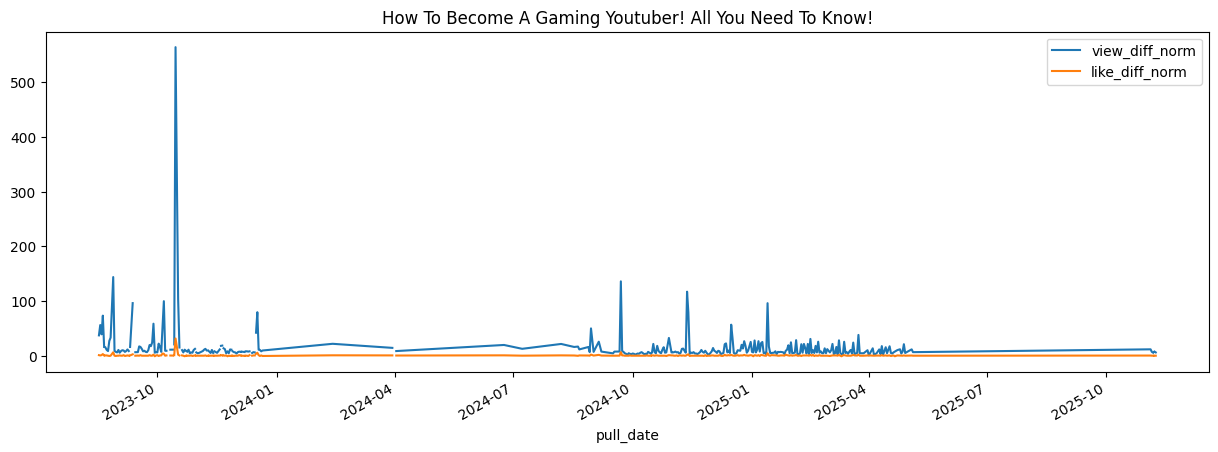

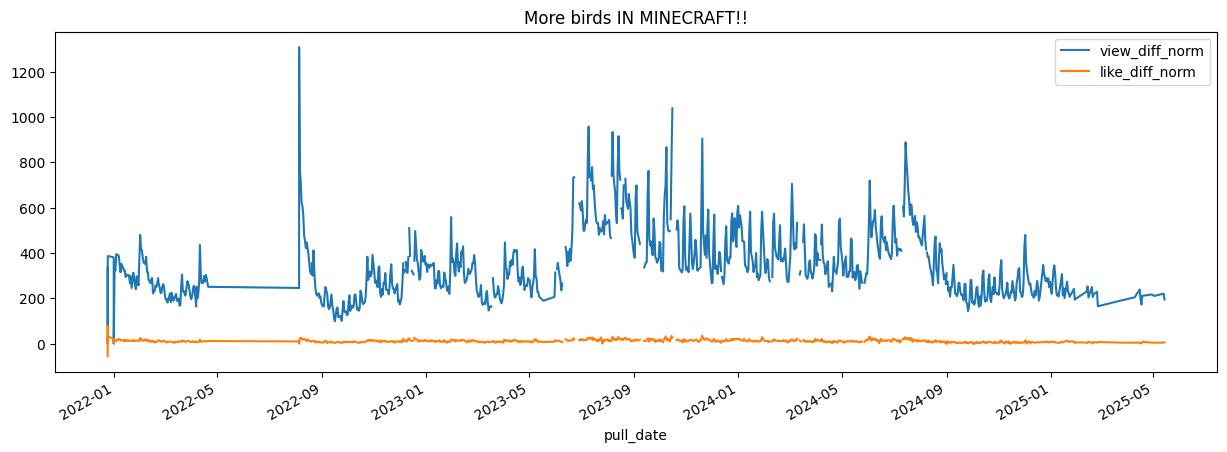

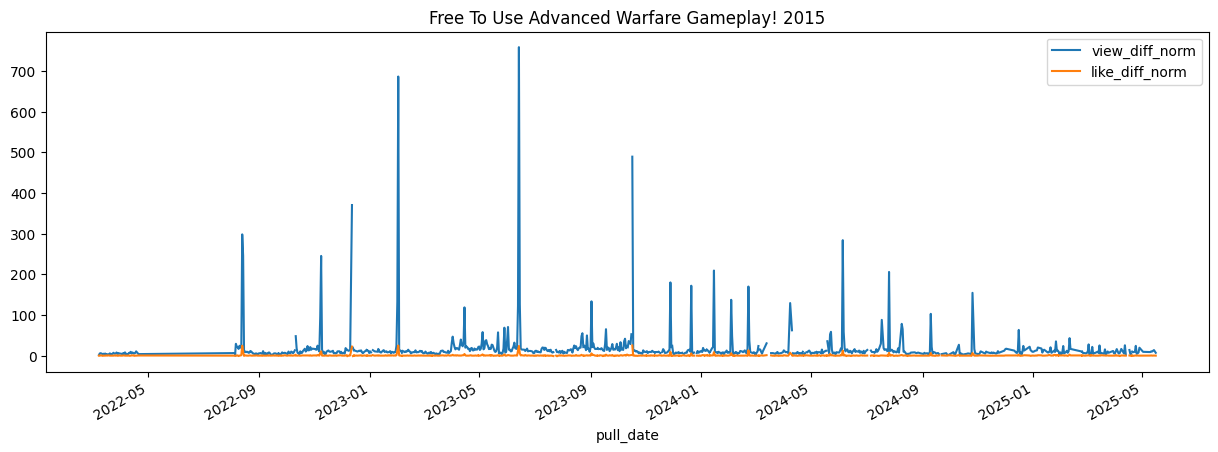

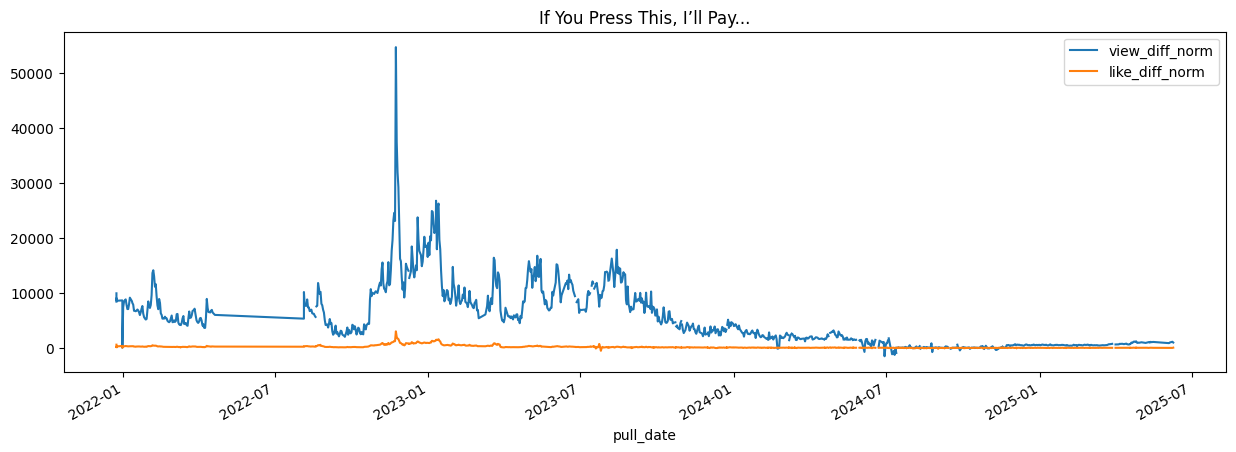

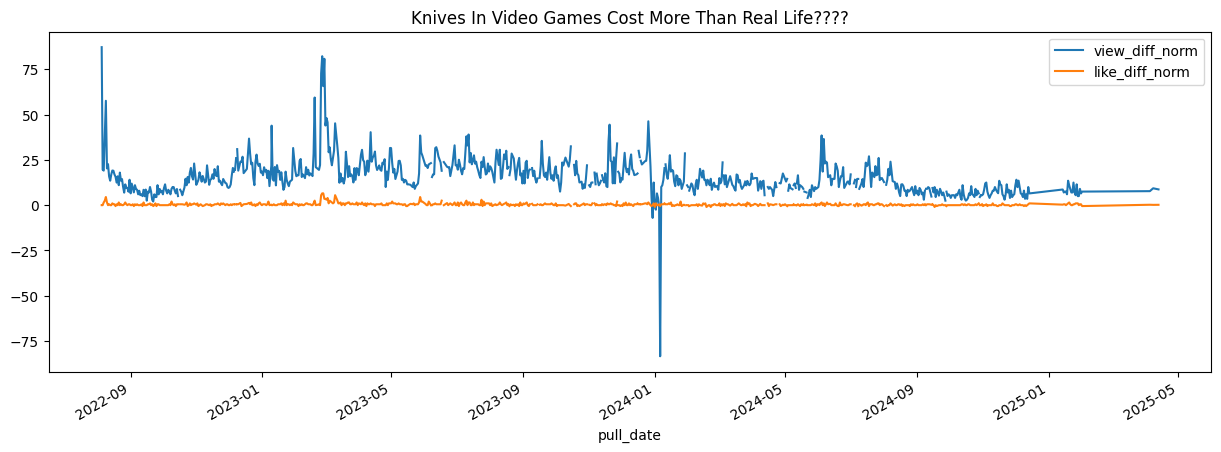

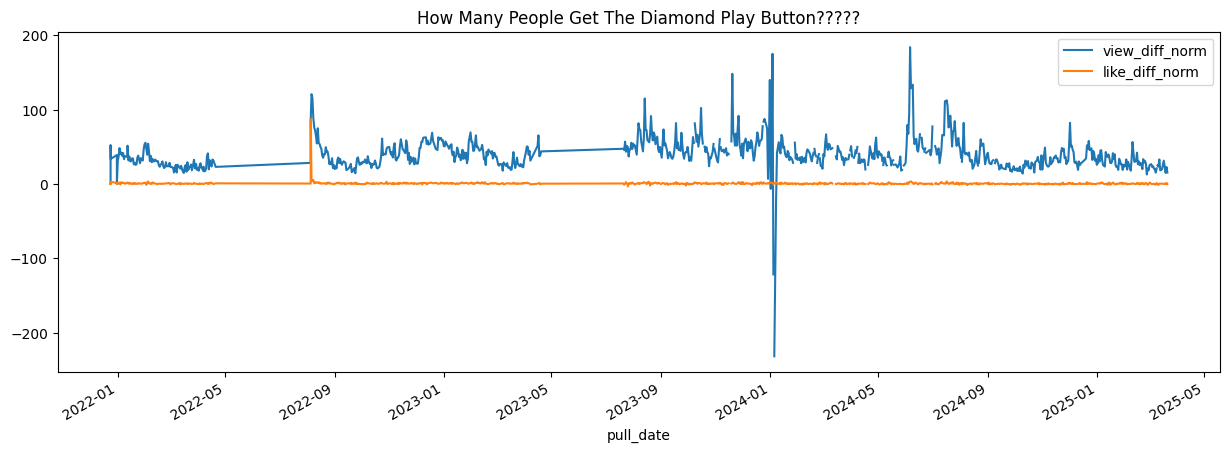

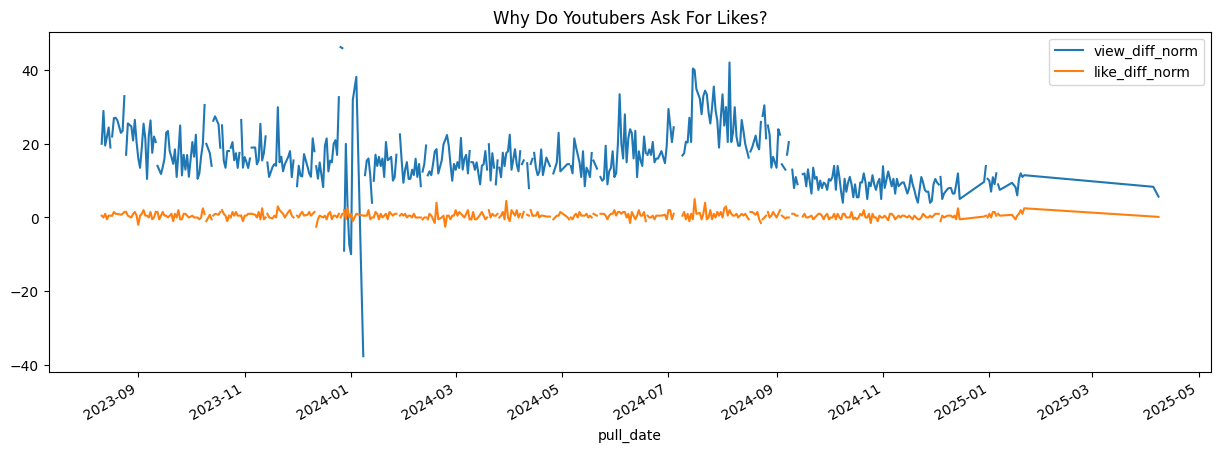

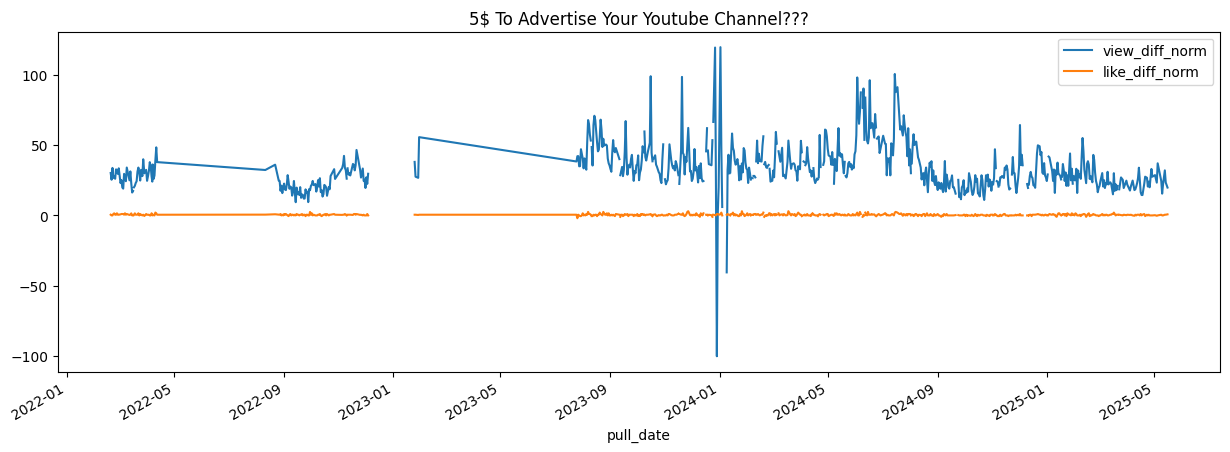

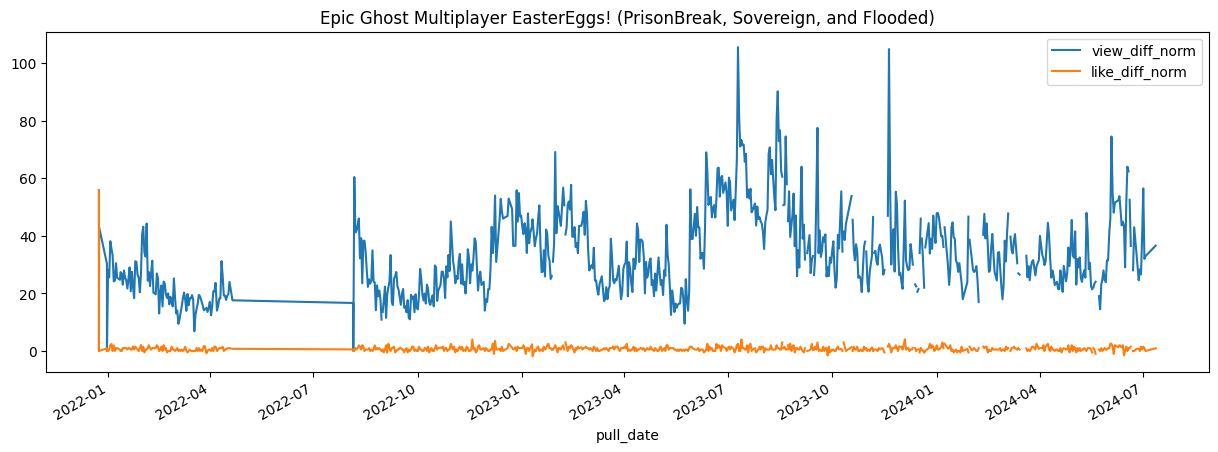

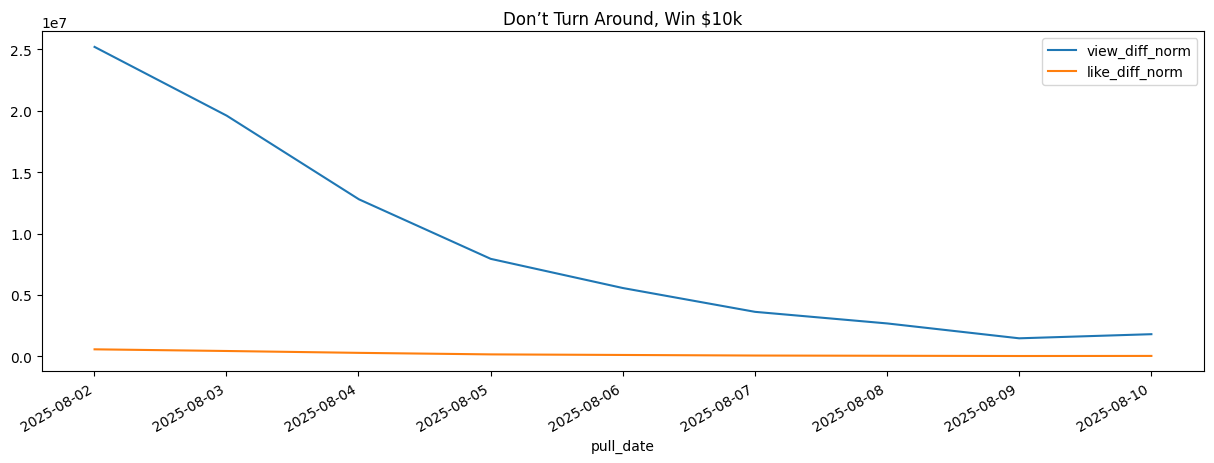

In [17]:
top_10_ids = ctx.sql('''
    SELECT id FROM (
        SELECT id, MAX(like_ratio_norm) AS max_ratio
        FROM youtube_final
        WHERE like_ratio_norm <= 1
          AND view_diff_norm != 0
        GROUP BY id
        ORDER BY max_ratio DESC
        LIMIT 10
    )
''').to_pandas()['id'].tolist()

for v in top_10_ids:
    vid_title = ctx.sql(
        f"SELECT title FROM youtube_final WHERE id = '{v}' LIMIT 1"
    ).to_pandas()['title'][0]
    query = f"SELECT pull_date, view_diff_norm, like_diff_norm FROM youtube_final WHERE id = '{v}' ORDER BY pull_date"
    (ctx.sql(query)
     .to_pandas()
     .set_index('pull_date')[['view_diff_norm', 'like_diff_norm']]
     .plot(figsize=(15, 5), title=vid_title))

In [18]:
ctx.sql('''
    SELECT view_count, like_count
    FROM youtube_clean
    WHERE id = 'se50viFJ0AQ'
''').to_pandas().corr()

,view_count,like_count
view_count,1.000000,0.992915
like_count,0.992915,1.000000


In [19]:
ctx.sql('SELECT * FROM youtube_final').to_pandas()

,id,title,pull_date,view_count,like_count,comment_count,duration_seconds,time_since_last_pull,view_diff,like_diff,comment_diff,like_to_view_ratio,view_diff_norm,like_diff_norm,like_ratio_norm
0,-0zoWMSEOGg,"I Gave My 6,000,000th Subscriber 6,000,000 ____",2021-12-24 01:41:03.667334+00:00,15052568,353973,33234,1113,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-0zoWMSEOGg,"I Gave My 6,000,000th Subscriber 6,000,000 ____",2021-12-24 01:53:57.197204+00:00,15052587,353973,33234,1113,0 days 00:12:53.529870,19.0,0.0,0.0,0.000000,1.061110e+03,0.000000,0.000000
2,-0zoWMSEOGg,"I Gave My 6,000,000th Subscriber 6,000,000 ____",2021-12-24 02:03:09.197822+00:00,15052593,353973,33234,1113,0 days 00:09:12.000618,6.0,0.0,0.0,0.000000,4.695647e+02,0.000000,0.000000
3,-0zoWMSEOGg,"I Gave My 6,000,000th Subscriber 6,000,000 ____",2021-12-24 02:16:53.157735+00:00,15052597,353973,33234,1113,0 days 00:13:43.959913,4.0,0.0,0.0,0.000000,2.097189e+02,0.000000,0.000000
4,-0zoWMSEOGg,"I Gave My 6,000,000th Subscriber 6,000,000 ____",2021-12-24 06:11:36.043167+00:00,15052769,353975,33234,1113,0 days 03:54:42.885432,172.0,2.0,0.0,0.011628,5.276191e+02,6.135106,0.011628
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
450884,zxuICI0kL3s,"Don’t Turn Around, Win $10k",2025-08-06 00:03:02.430098+00:00,158436656,3666206,5532,31,1 days 00:00:54.740390,11132526.0,225526.0,273.0,0.020258,5.562739e+06,112691.602057,0.020258
450885,zxuICI0kL3s,"Don’t Turn Around, Win $10k",2025-08-07 00:04:31.258029+00:00,165692474,3798626,5612,31,1 days 00:01:28.827931,7255818.0,132420.0,80.0,0.018250,3.624183e+06,66141.999341,0.018250
450886,zxuICI0kL3s,"Don’t Turn Around, Win $10k",2025-08-08 00:06:04.659983+00:00,171056625,3893536,5719,31,1 days 00:01:33.401954,5364151.0,94910.0,107.0,0.017693,2.679179e+06,47403.754591,0.017693
450887,zxuICI0kL3s,"Don’t Turn Around, Win $10k",2025-08-09 00:04:03.468001+00:00,173990638,3949685,5803,31,0 days 23:57:58.808018,2934013.0,56149.0,84.0,0.019137,1.469067e+06,28113.934994,0.019137


<Axes: ylabel='Frequency'>

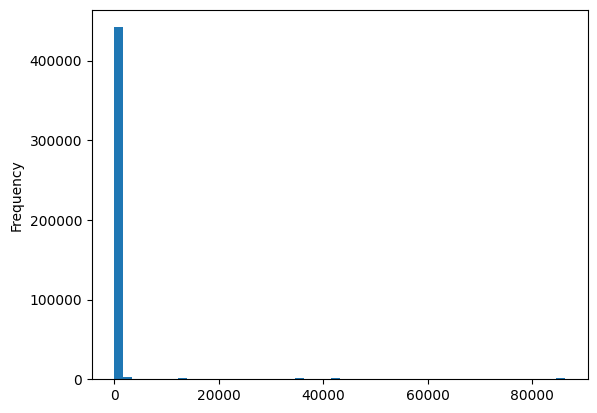

In [20]:
ctx.sql('SELECT duration_seconds FROM youtube_final').to_pandas()['duration_seconds'].plot(kind='hist', bins=50)

<Axes: ylabel='Frequency'>

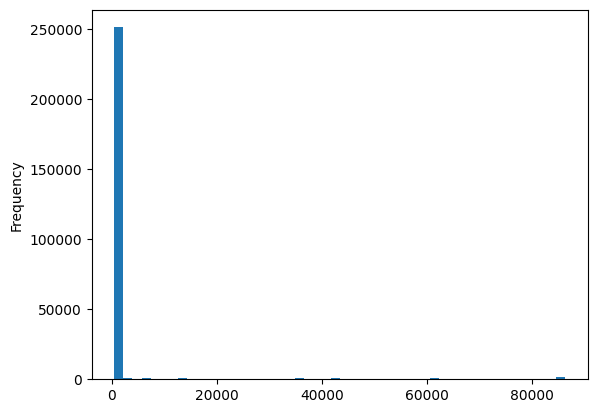

In [21]:
ctx.sql('''
    SELECT duration_seconds FROM youtube_final
    WHERE duration_seconds > 500
''').to_pandas()['duration_seconds'].plot(kind='hist', bins=50)

In [22]:
# Get the latest snapshot per video using the ROW_NUMBER() window function
ctx.sql('''
    CREATE OR REPLACE VIEW latest_videos AS
    SELECT * FROM (
        SELECT *,
               ROW_NUMBER() OVER (PARTITION BY id ORDER BY pull_date DESC) AS rn
        FROM youtube_final
    )
    WHERE rn = 1
''')

No data to display

In [23]:
ctx.sql('''
    SELECT *,
        CAST(comment_count AS DOUBLE) / NULLIF(CAST(view_count AS DOUBLE), 0.0) AS comment_ratio
    FROM latest_videos
    WHERE view_count > 1000000
    ORDER BY comment_ratio DESC
''').show()

DataFrame()
+-------------+-----------------------------------------------------+-----------------------------+------------+------------+---------------+------------------+----------------------+-----------+-----------+--------------+-----------------------+--------------------+---------------------+-----------------------+----+-----------------------+
| id          | title                                               | pull_date                   | view_count | like_count | comment_count | duration_seconds | time_since_last_pull | view_diff | like_diff | comment_diff | like_to_view_ratio    | view_diff_norm     | like_diff_norm      | like_ratio_norm       | rn | comment_ratio         |
+-------------+-----------------------------------------------------+-----------------------------+------------+------------+---------------+------------------+----------------------+-----------+-----------+--------------+-----------------------+--------------------+---------------------+-------------